In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [1]:
# Merge Sort

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr)//2
        left = arr[:mid]
        right = arr[mid:]

        merge_sort(left)
        merge_sort(right)

        i=j=k=0

        while i < len(left) and j < len(right):
            if left[i] < right[j]:
                arr[k] = left[i]
                i+=1
            else:
                arr[k] = right[j]
                j+=1
            k+=1

        while i < len(left):
            arr[k] = left[i]
            i+=1
            k+=1

        while j < len(right):
            arr[k] = right[j]
            j+=1
            k+=1

arr=[38,27,43,3,9,82]
merge_sort(arr)
print("Sorted Array:",arr)

Sorted Array: [3, 9, 27, 38, 43, 82]


In [2]:
# Quick Sort

def partition(arr,low,high):
    pivot=arr[low]
    i=low+1
    j=high

    while True:
        while i<=j and arr[i]<=pivot:
            i+=1
        while i<=j and arr[j]>=pivot:
            j-=1

        if i<=j:
            arr[i],arr[j]=arr[j],arr[i]
        else:
            break

    arr[low],arr[j]=arr[j],arr[low]
    return j


def quick_sort(arr,low,high):
    if low<high:
        p=partition(arr,low,high)
        quick_sort(arr,low,p-1)
        quick_sort(arr,p+1,high)

arr=[1,2,3,4,5]
quick_sort(arr,0,len(arr)-1)

print("Sorted:",arr)

Sorted: [1, 2, 3, 4, 5]


In [3]:
# Fractional Knapsack

def fractional_knapsack(value,weight,capacity):

    items=list(range(len(value)))
    ratio=[v/w for v,w in zip(value,weight)]

    items.sort(key=lambda i: ratio[i],reverse=True)

    total_value=0

    for i in items:
        if weight[i]<=capacity:
            capacity-=weight[i]
            total_value+=value[i]

        else:
            total_value+=ratio[i]*capacity
            break

    return total_value


value=[6,2,1,8,3,5]
weight=[6,10,3,5,1,3]

print("Maximum Value:",fractional_knapsack(value,weight,16))

Maximum Value: 22.333333333333332


In [4]:
# Job Sequencing with Deadline

def job_sequencing(jobs):

    jobs.sort(key=lambda x:x[2],reverse=True)

    max_deadline=max(jobs,key=lambda x:x[1])[1]

    slots=[None]*(max_deadline+1)

    profit=0

    for job in jobs:
        for j in range(job[1],0,-1):

            if slots[j]==None:
                slots[j]=job[0]
                profit+=job[2]
                break

    return slots,profit


jobs=[
('J1',1,3),
('J2',3,5),
('J3',4,20),
('J4',3,18),
('J5',2,1),
('J6',1,6),
('J7',2,30)
]

schedule,profit=job_sequencing(jobs)

print("Schedule:",schedule)
print("Maximum Profit:",profit)

Schedule: [None, 'J6', 'J7', 'J4', 'J3']
Maximum Profit: 74


In [5]:
# Longest Common Subsequence

def LCS(X,Y):

    m=len(X)
    n=len(Y)

    dp=[[0]*(n+1) for i in range(m+1)]

    for i in range(1,m+1):
        for j in range(1,n+1):

            if X[i-1]==Y[j-1]:
                dp[i][j]=dp[i-1][j-1]+1

            else:
                dp[i][j]=max(dp[i-1][j],dp[i][j-1])

    return dp[m][n]


X="10010101"
Y="010110110"

print("Length of LCS:",LCS(X,Y))

Length of LCS: 6


In [6]:
# 0/1 Knapsack using Dynamic Programming

def knapsack(W,wt,val,n):

    K=[[0 for x in range(W+1)] for x in range(n+1)]

    for i in range(n+1):
        for w in range(W+1):

            if i==0 or w==0:
                K[i][w]=0

            elif wt[i-1]<=w:
                K[i][w]=max(val[i-1]+K[i-1][w-wt[i-1]],K[i-1][w])

            else:
                K[i][w]=K[i-1][w]

    return K[n][W]


val=[100,50,20,10,7,3]
wt=[100,50,20,10,7,3]
W=165

print("Maximum Value:",knapsack(W,wt,val,len(val)))

Maximum Value: 163


In [7]:
# Travelling Salesman Problem

import itertools

def tsp(graph):

    n=len(graph)
    vertices=list(range(1,n))

    min_path=999999

    for perm in itertools.permutations(vertices):

        cost=0
        k=0

        for j in perm:
            cost+=graph[k][j]
            k=j

        cost+=graph[k][0]

        min_path=min(min_path,cost)

    return min_path


graph=[
[0,10,15,20],
[10,0,35,25],
[15,35,0,30],
[20,25,30,0]
]

print("Minimum TSP Cost:",tsp(graph))

Minimum TSP Cost: 80


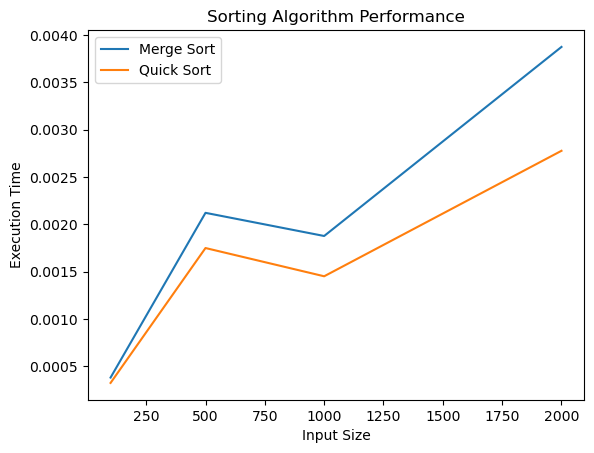

In [9]:
sizes=[100,500,1000,2000]

merge_times=[]
quick_times=[]

def merge_sort(arr):
    if len(arr)>1:
        mid=len(arr)//2
        L=arr[:mid]
        R=arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i=j=k=0

        while i<len(L) and j<len(R):
            if L[i]<R[j]:
                arr[k]=L[i]
                i+=1
            else:
                arr[k]=R[j]
                j+=1
            k+=1

        while i<len(L):
            arr[k]=L[i]
            i+=1
            k+=1

        while j<len(R):
            arr[k]=R[j]
            j+=1
            k+=1


def quick_sort(arr):
    if len(arr)<=1:
        return arr

    pivot=arr[0]

    left=[x for x in arr[1:] if x<=pivot]
    right=[x for x in arr[1:] if x>pivot]

    return quick_sort(left)+[pivot]+quick_sort(right)


for size in sizes:

    arr=[random.randint(1,1000) for i in range(size)]

    start=time.time()
    merge_sort(arr.copy())
    merge_times.append(time.time()-start)

    start=time.time()
    quick_sort(arr.copy())
    quick_times.append(time.time()-start)


plt.plot(sizes,merge_times,label="Merge Sort")
plt.plot(sizes,quick_times,label="Quick Sort")

plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.title("Sorting Algorithm Performance")

plt.legend()
plt.show()